
Validation Results Comparison:
              model  params  accuracy  balanced_acc        f1    recall
2     Random Forest   200.0  0.922791      0.610972  0.339523  0.236162
1     Random Forest   100.0  0.921860      0.608789  0.333333  0.232472
4               SVM     1.0  0.625116      0.681411  0.251393  0.749077
3               SVM     0.1  0.598140      0.665009  0.237647  0.745387
0               kNN    11.0  0.923101      0.565896  0.229814  0.136531
5  Gradient Bagging     0.8  0.922171      0.541928  0.154882  0.084871
6  Gradient Bagging     1.0  0.921860      0.541758  0.154362  0.084871

Final Test Set Results (Best Threshold: 0.25)
Accuracy: 0.8831
Balanced Accuracy: 0.6892
F1 Score: 0.3968


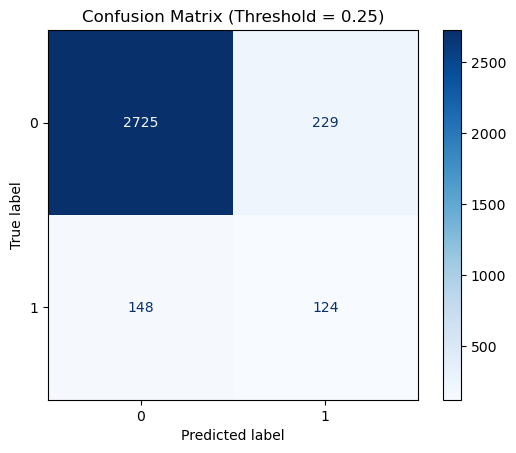

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
)

# Global Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. Data Loading & Feature Engineering
df_raw = pd.read_csv('data/processed/acn_sessions_flat.csv')

# Parse the JSON data in userInputs
def parse_inputs(val):
    try:
        data = ast.literal_eval(val)
        return data[0] if isinstance(data, list) and len(data) > 0 else {}
    except: return {}

user_features = df_raw['userInputs'].apply(parse_inputs).apply(pd.Series)
df = pd.concat([df_raw, user_features], axis=1)

# Definition of time and target variables
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['disconnectTime'] = pd.to_datetime(df['disconnectTime'])
df['hour'] = df['connectionTime'].dt.hour
df['day_of_week'] = df['connectionTime'].dt.dayofweek
df['duration_hrs'] = (df['disconnectTime'] - df['connectionTime']).dt.total_seconds() / 3600

# Predict whether it is a long-term occupation 
df['is_long_session'] = (df['duration_hrs'] > 10).astype(int)


df['siteID'] = df['siteID'].astype(str)


# 2. Train/Val/Test Split (60/20/20)

target = "is_long_session"
X = df[['hour', 'day_of_week', 'kWhRequested', 'kWhDelivered', 'siteID']].copy()
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)


# 3. Preprocessing Pipelines

numeric_features = ["hour", "day_of_week", "kWhRequested", "kWhDelivered"]
categorical_features = ["siteID"]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# 4. Model Competition & Hyperparameter Tuning

results_list = []

# define model config
models_config = {
    "kNN": {"model": KNeighborsClassifier(), "params": [11], "p_name": "n_neighbors"},
    "Random Forest": {"model": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE), "params": [100, 200], "p_name": "n_estimators"},
    "SVM": {"model": SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE), "params": [0.1, 1.0], "p_name": "C"},
    "Gradient Bagging": {
        "model": BaggingClassifier(estimator=GradientBoostingClassifier(random_state=RANDOM_STATE), random_state=RANDOM_STATE),
        "params": [0.8, 1.0], "p_name": "max_samples"
    }
}

for name, config in models_config.items():
    for p in config["params"]:
        clf = config["model"]
        setattr(clf, config["p_name"], p)
        
        pipe = Pipeline(steps=[("pre", preprocess), ("clf", clf)])
        pipe.fit(X_train, y_train)
        
        y_val_pred = pipe.predict(X_val)
        y_val_proba = pipe.predict_proba(X_val)[:, 1] if hasattr(pipe, "predict_proba") else None
        
        results_list.append({
            "model": name, "params": p,
            "accuracy": accuracy_score(y_val, y_val_pred),
            "balanced_acc": balanced_accuracy_score(y_val, y_val_pred), 
            "f1": f1_score(y_val, y_val_pred),
            "recall": recall_score(y_val, y_val_pred)
        })

results_df = pd.DataFrame(results_list)
print("\nValidation Results Comparison:")
print(results_df.sort_values(by="f1", ascending=False))

# 5. Final Model Selection & Threshold Tuning
# Assuming that 200 Random Forests are selected based on F1 
best_clf = RandomForestClassifier(
    n_estimators=200, 
    class_weight="balanced", 
    random_state=RANDOM_STATE
)

final_pipeline = Pipeline(steps=[("pre", preprocess), ("clf", best_clf)])
final_pipeline.fit(X_train, y_train)

# Threshold Optimisation (for F1 Score)
y_val_proba = final_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0, 1, 101)
f1_scores = [f1_score(y_val, (y_val_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]


X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
final_pipeline.fit(X_trainval, y_trainval)

y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_t).astype(int)


# Final Evaluation
print(f"\nFinal Test Set Results (Best Threshold: {best_t:.2f})")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_test_pred):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {best_t:.2f})")
plt.show()